In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving circuits.csv to circuits.csv
Saving constructor_standings.csv to constructor_standings.csv
Saving constructors.csv to constructors.csv
Saving driver_standings.csv to driver_standings.csv


In [3]:
circuits = pd.read_csv("circuits.csv")
constructors = pd.read_csv("constructors.csv")
constructor_standings = pd.read_csv("constructor_standings.csv")
driver_standings = pd.read_csv("driver_standings.csv")

In [4]:
print(" CIRCUITS DATA")
print(circuits.head())
print(" CONSTRUCTORS DATA")
print(constructors.head())
print(" CONSTRUCTOR STANDINGS")
print(constructor_standings.head())
print(" DRIVER STANDINGS")
print(driver_standings.head())

 CIRCUITS DATA
    circuit_id                            name       city     country  \
0  albert_park  Albert Park Grand Prix Circuit  Melbourne   Australia   
1     americas         Circuit of the Americas     Austin         USA   
2      bahrain   Bahrain International Circuit     Sakhir     Bahrain   
3         baku               Baku City Circuit       Baku  Azerbaijan   
4    catalunya  Circuit de Barcelona-Catalunya  Barcelona       Spain   

       lat        lng                                                url  
0 -37.8497  144.96800  https://en.wikipedia.org/wiki/Albert_Park_Circuit  
1  30.1328  -97.64110  https://en.wikipedia.org/wiki/Circuit_of_the_A...  
2  26.0325   50.51060  https://en.wikipedia.org/wiki/Bahrain_Internat...  
3  40.3725   49.85330    https://en.wikipedia.org/wiki/Baku_City_Circuit  
4  41.5700    2.26111  https://en.wikipedia.org/wiki/Circuit_de_Barce...  
 CONSTRUCTORS DATA
  constructor_id            name nationality  \
0         alpine  Alpine F1 T

In [5]:
print("\n===================================")
print(" DATASET INFORMATION")
print("===================================")

print("\n CIRCUITS INFO")
print(circuits.info())

print("\n CONSTRUCTORS INFO")
print(constructors.info())

print("\n DRIVER STANDINGS INFO")
print(driver_standings.info())


 DATASET INFORMATION

 CIRCUITS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuit_id  25 non-null     object 
 1   name        25 non-null     object 
 2   city        25 non-null     object 
 3   country     25 non-null     object 
 4   lat         25 non-null     float64
 5   lng         25 non-null     float64
 6   url         25 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.5+ KB
None

 CONSTRUCTORS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructor_id  12 non-null     object
 1   name            12 non-null     object
 2   nationality     12 non-null     object
 3   url             12 non-null     object
dtypes: object(4)
memory usage: 516.0+ bytes
Non

In [6]:
print("\n===================================")
print(" NULL VALUES")
print("===================================")

print("\n CIRCUITS NULL VALUES")
print(circuits.isnull().sum())

print("\n CONSTRUCTORS NULL VALUES")
print(constructors.isnull().sum())

print("\n DRIVER STANDINGS NULL VALUES")
print(driver_standings.isnull().sum())


 NULL VALUES

 CIRCUITS NULL VALUES
circuit_id    0
name          0
city          0
country       0
lat           0
lng           0
url           0
dtype: int64

 CONSTRUCTORS NULL VALUES
constructor_id    0
name              0
nationality       0
url               0
dtype: int64

 DRIVER STANDINGS NULL VALUES
season            0
round             0
position          8
points            0
wins              0
driver_id         0
driver_name       0
driver_nat        0
constructor_id    0
constructor       0
dtype: int64


In [7]:

circuits.drop_duplicates(inplace=True)
constructors.drop_duplicates(inplace=True)
constructor_standings.drop_duplicates(inplace=True)
driver_standings.drop_duplicates(inplace=True)

print("\n DUPLICATES REMOVED SUCCESSFULLY")


 DUPLICATES REMOVED SUCCESSFULLY


In [8]:
circuits.fillna(method='ffill', inplace=True)
constructors.fillna(method='ffill', inplace=True)
constructor_standings.fillna(method='ffill', inplace=True)
driver_standings.fillna(method='ffill', inplace=True)

print("\n MISSING VALUES FILLED")


 MISSING VALUES FILLED



 GENERATING DRIVER STANDINGS GRAPH...


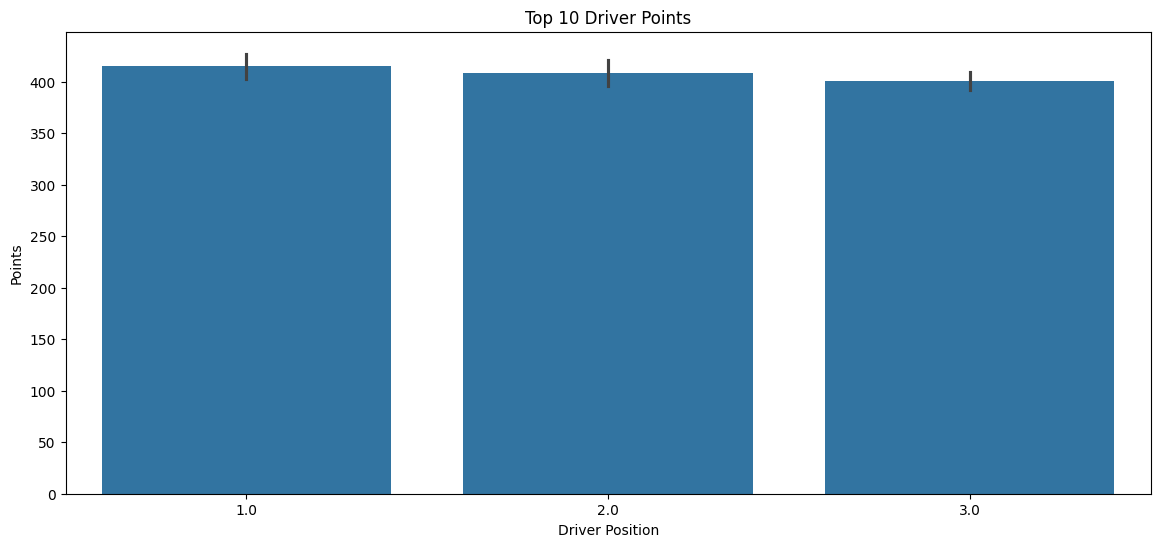

In [9]:
print("\n GENERATING DRIVER STANDINGS GRAPH...")

plt.figure(figsize=(14,6))

top_drivers = driver_standings.sort_values(
    by='points',
    ascending=False
).head(10)

sns.barplot(
    x='position',
    y='points',
    data=top_drivers
)

plt.title("Top 10 Driver Points")
plt.xlabel("Driver Position")
plt.ylabel("Points")

plt.show()

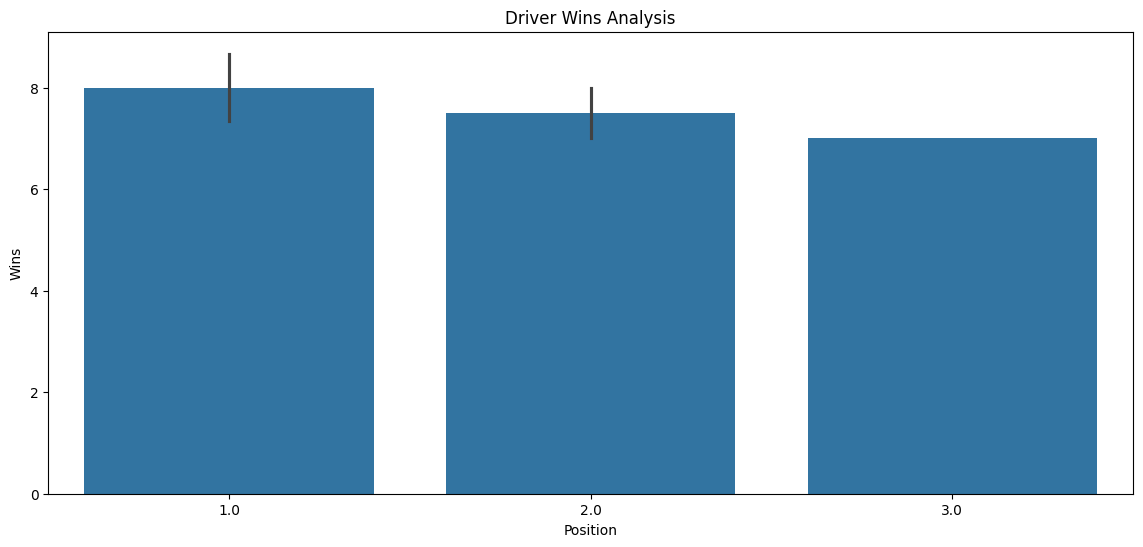

In [10]:
if 'wins' in driver_standings.columns:

    plt.figure(figsize=(14,6))

    sns.barplot(
        x='position',
        y='wins',
        data=top_drivers
    )

    plt.title("Driver Wins Analysis")
    plt.xlabel("Position")
    plt.ylabel("Wins")

    plt.show()


 GENERATING CONSTRUCTOR ANALYSIS...


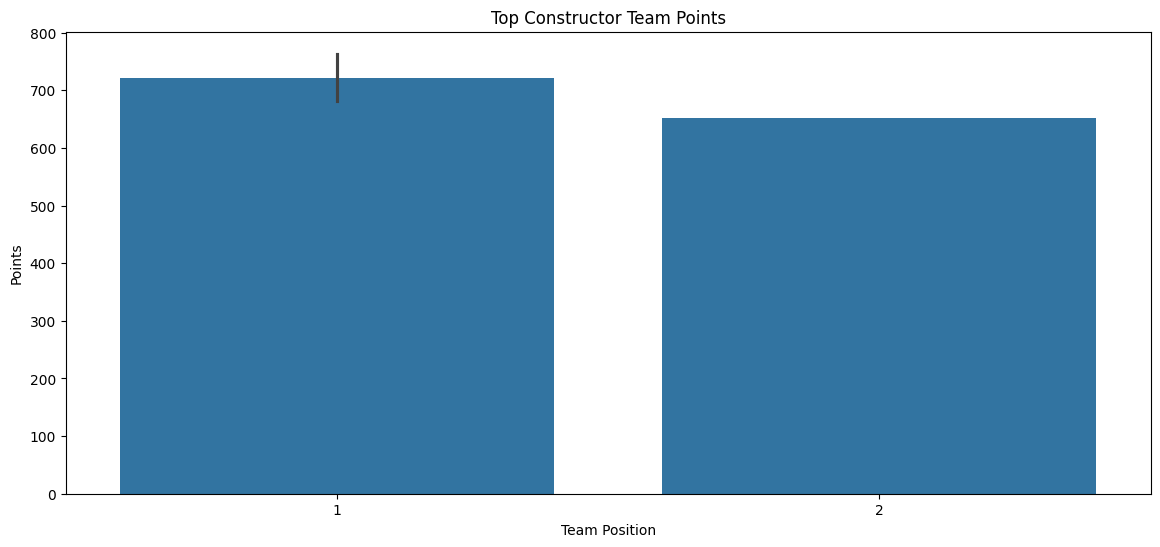

In [11]:
print("\n GENERATING CONSTRUCTOR ANALYSIS...")

plt.figure(figsize=(14,6))

top_teams = constructor_standings.sort_values(
    by='points',
    ascending=False
).head(10)

sns.barplot(
    x='position',
    y='points',
    data=top_teams
)

plt.title("Top Constructor Team Points")
plt.xlabel("Team Position")
plt.ylabel("Points")

plt.show()


 GENERATING CIRCUIT ANALYSIS...


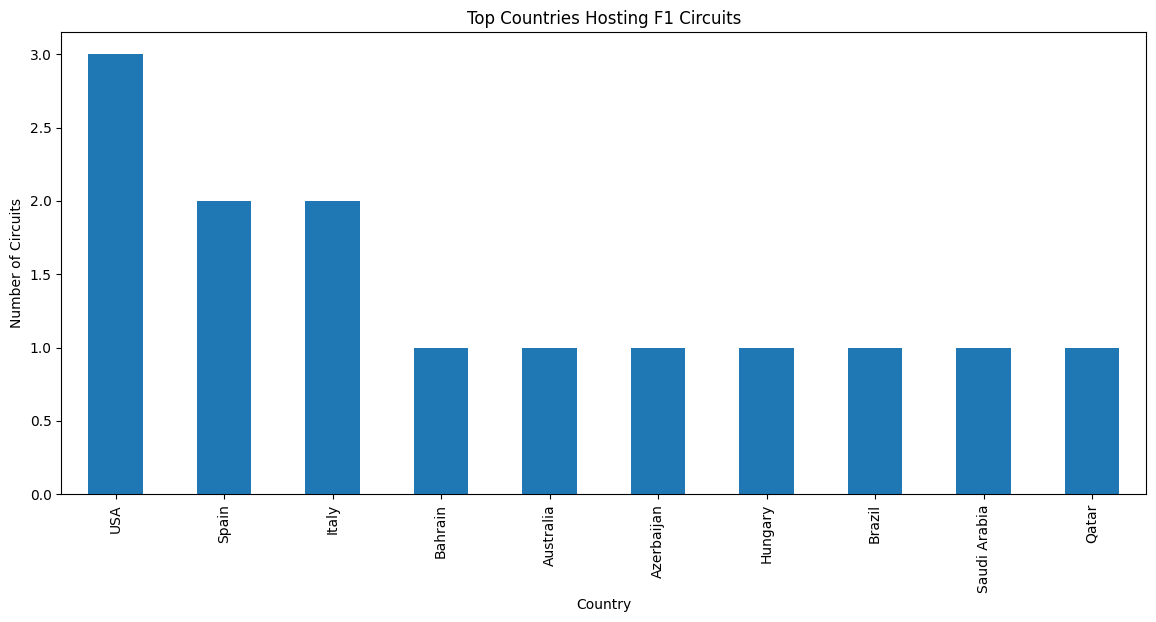

In [12]:
print("\n GENERATING CIRCUIT ANALYSIS...")

if 'country' in circuits.columns:

    country_count = circuits['country'].value_counts().head(10)

    plt.figure(figsize=(14,6))

    country_count.plot(kind='bar')

    plt.title("Top Countries Hosting F1 Circuits")
    plt.xlabel("Country")
    plt.ylabel("Number of Circuits")

    plt.show()

In [13]:
if 'location' in circuits.columns:

    top_locations = circuits['location'].value_counts().head(10)

    plt.figure(figsize=(14,6))

    top_locations.plot(kind='pie', autopct='%1.1f%%')

    plt.title("Circuit Location Distribution")

    plt.ylabel("")

    plt.show()


 GENERATING HEATMAP...


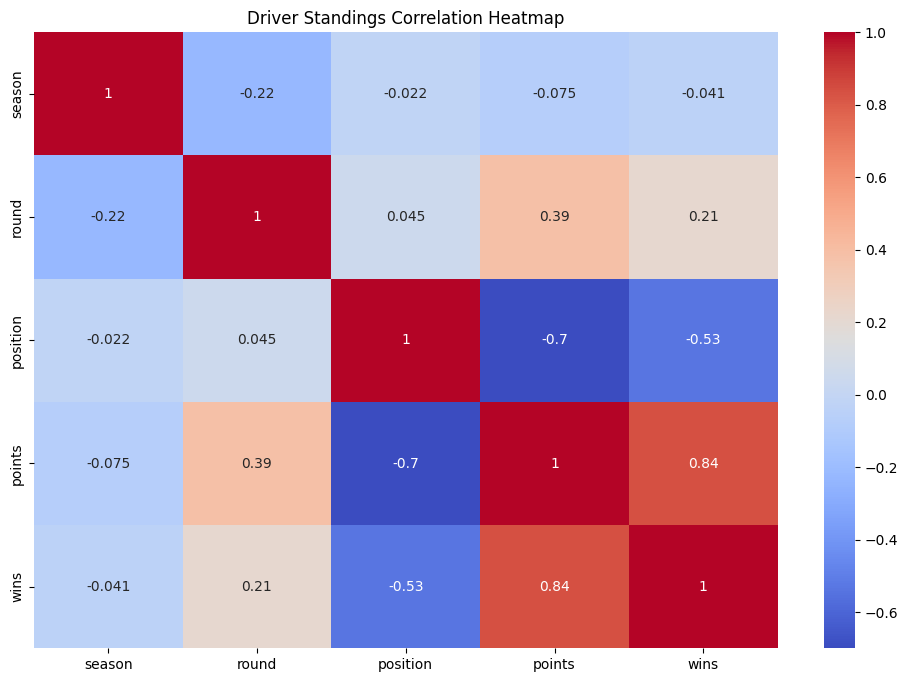

In [14]:
print("\n GENERATING HEATMAP...")

plt.figure(figsize=(12,8))

numeric_df = driver_standings.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Driver Standings Correlation Heatmap")

plt.show()


 GENERATING PERFORMANCE TREND...


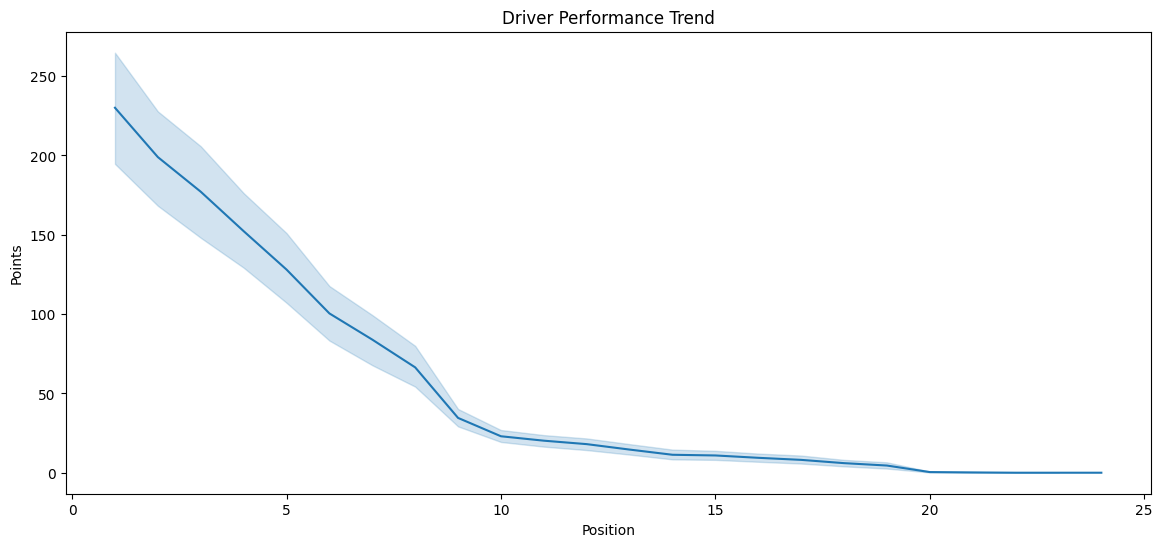

In [15]:
print("\n GENERATING PERFORMANCE TREND...")

plt.figure(figsize=(14,6))

sns.lineplot(
    x='position',
    y='points',
    data=driver_standings
)

plt.title("Driver Performance Trend")
plt.xlabel("Position")
plt.ylabel("Points")

plt.show()

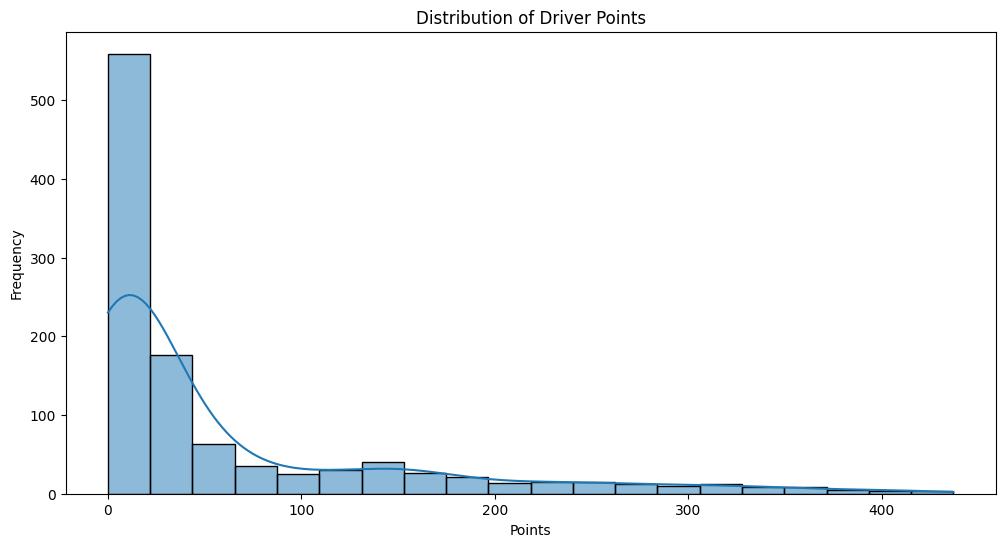

In [16]:
plt.figure(figsize=(12,6))

sns.histplot(
    driver_standings['points'],
    bins=20,
    kde=True
)

plt.title("Distribution of Driver Points")

plt.xlabel("Points")
plt.ylabel("Frequency")

plt.show()

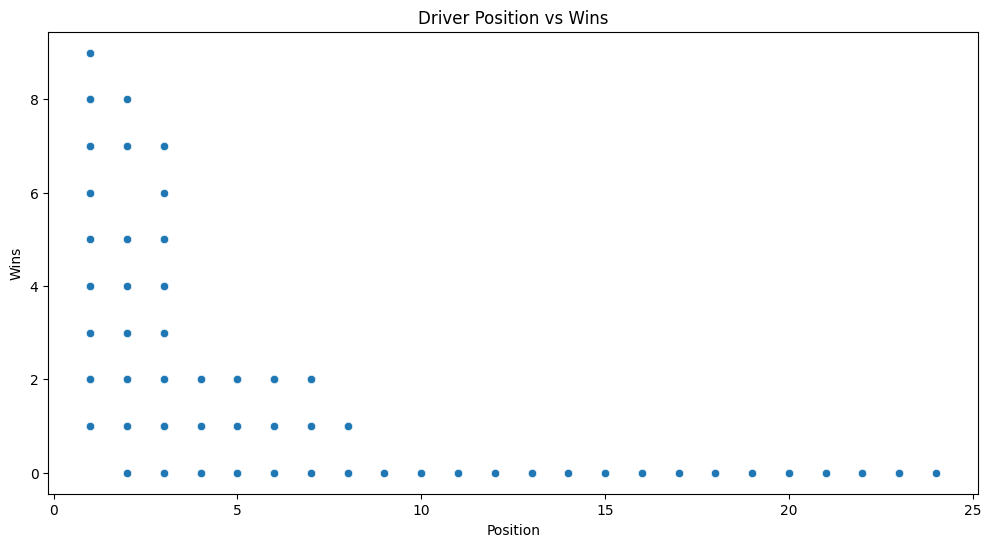

In [17]:
if 'wins' in driver_standings.columns:

    plt.figure(figsize=(12,6))

    sns.scatterplot(
        x='position',
        y='wins',
        data=driver_standings
    )

    plt.title("Driver Position vs Wins")

    plt.xlabel("Position")
    plt.ylabel("Wins")

    plt.show()

In [18]:
print("\n===================================")
print(" DRIVER STANDINGS SUMMARY")
print("===================================")

print(driver_standings.describe())

print("\n===================================")
print(" CONSTRUCTOR STANDINGS SUMMARY")
print("===================================")

print(constructor_standings.describe())


 DRIVER STANDINGS SUMMARY
            season        round     position       points         wins
count  1083.000000  1083.000000  1083.000000  1083.000000  1083.000000
mean   2024.581717    12.043398    11.114497    61.169898     0.559557
std       0.604602     7.191657     6.139611    91.242313     1.504432
min    2024.000000     1.000000     1.000000     0.000000     0.000000
25%    2024.000000     6.000000     6.000000     4.000000     0.000000
50%    2025.000000    12.000000    11.000000    20.000000     0.000000
75%    2025.000000    18.000000    16.000000    73.000000     0.000000
max    2026.000000    24.000000    24.000000   437.000000     9.000000

 CONSTRUCTOR STANDINGS SUMMARY
            season       round    position      points        wins
count   513.000000  513.000000  513.000000  513.000000  513.000000
mean   2024.596491   11.824561    5.532164  129.136452    1.181287
std       0.608330    7.184267    2.897237  173.955771    2.588338
min    2024.000000    1.000000    

In [19]:
print("\n===================================")
print(" TOP 10 DRIVERS")
print("===================================")

print(
    top_drivers[
        ['position', 'points']
    ]
)


 TOP 10 DRIVERS
     position  points
495       1.0   437.0
472       1.0   429.0
996       1.0   423.0
997       2.0   421.0
998       3.0   410.0
975       1.0   408.0
449       1.0   403.0
976       2.0   396.0
426       1.0   393.0
977       3.0   392.0


In [20]:
print("\n===================================")
print(" TOP 10 CONSTRUCTORS")
print("===================================")

print(
    top_teams[
        ['position', 'points']
    ]
)


 TOP 10 CONSTRUCTORS
     position  points
470         1   833.0
460         1   800.0
450         1   756.0
440         1   756.0
430         1   713.0
420         1   678.0
230         1   666.0
231         2   652.0
410         1   650.0
220         1   640.0


In [21]:
driver_standings.to_csv(
    "clean_driver_standings.csv",
    index=False
)

constructor_standings.to_csv(
    "clean_constructor_standings.csv",
    index=False
)

print("\n CLEANED FILES SAVED SUCCESSFULLY")


 CLEANED FILES SAVED SUCCESSFULLY


In [22]:
files.download("clean_driver_standings.csv")
files.download("clean_constructor_standings.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
print("\n===================================")
print(" FORMULA ONE LIVE TRACKER COMPLETED ")
print("===================================")

print("""
PROJECT FEATURES COMPLETED:

1. Driver standings analysis
2. Constructor standings analysis
3. Circuit country analysis
4. Driver wins analysis
5. Heatmap visualization
6. Performance trend analysis
7. Statistical summary
8. Clean dataset export

TECHNOLOGIES USED:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

THANK YOU
""")


 FORMULA ONE LIVE TRACKER COMPLETED 

PROJECT FEATURES COMPLETED:

1. Driver standings analysis
2. Constructor standings analysis
3. Circuit country analysis
4. Driver wins analysis
5. Heatmap visualization
6. Performance trend analysis
7. Statistical summary
8. Clean dataset export

TECHNOLOGIES USED:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

THANK YOU

